# ARIMA model

In [42]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

In [43]:
# Load the data
df = pd.read_csv("data/Daily.csv")
df = df[["Date", "USD"]]
df['USD'] = df['USD'].str.replace(',', '')
df["USD"] = pd.to_numeric(df["USD"])
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y") # Parse dates
df = df[df["Date"] >= "2010-01-01"]
df = df.dropna()
df = df.reset_index(drop=True) # Sort by date
df = df.set_index("Date") # Set date as index

In [44]:
trading_days_per_year = 252

C:\Users\Ryan Joo\AppData\Local\Temp\ipykernel_20920\1756641383.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


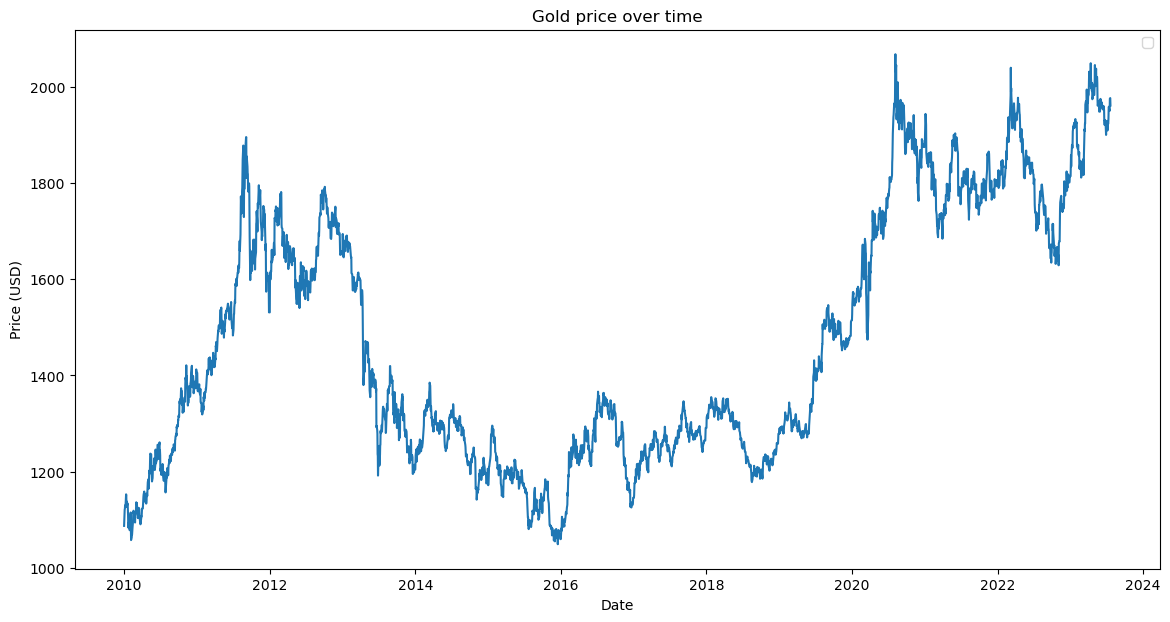

In [45]:
# Create a time plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["USD"])
plt.title(f'Gold price over time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [46]:
# Check for stationarity
result_original = adfuller(df["USD"])
p_value_original = result_original[1]
print(f"p-value: {p_value_original:.4f}")
if p_value_original < 0.05: # compare p-value with sig level
    print("The original series is stationary")
else:
    print("The original series is non-stationary")

p-value: 0.6573
The original series is non-stationary


In [47]:
# Repeatedly difference the time series until it becomes stationary
d = 0
df["Gold_diff"] = df["USD"]
p_value_diff = p_value_original

while p_value_diff >= 0.05:
    # Apply differencing
    df["Gold_diff"] = df["Gold_diff"].diff()

    # Perform Augmented Dickey-Fuller test on the differenced series
    result_diff = adfuller(df["Gold_diff"].dropna())
    p_value_diff = result_diff[1]
    d += 1

print(f"Value of d: {d}")
print(p_value_diff)

Value of d: 1
8.57443325934296e-25


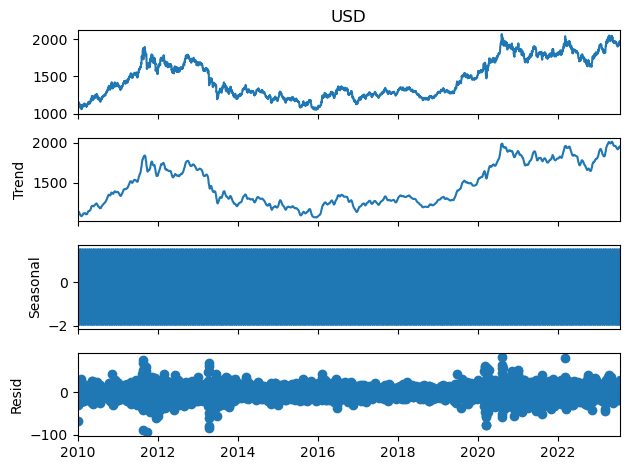

In [48]:
# Check for seasonality by performing classical decomposition
import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(df["USD"], model='additive', extrapolate_trend='freq', period=12)
fig = decomposition.plot()
plt.show()

In [49]:
trend = decomposition.trend.dropna()

In [ ]:
# Forecasting
test_period = trading_days_per_year * 5
train_period = len(trend) - test_period
window_size = trading_days_per_year

model = pm.auto_arima(
    trend.iloc[:train_period], 
    start_p=0, max_p=5, 
    start_q=0, max_q=5,
    d=d,
    seasonal=False,
    trace=True, 
    error_action='ignore', 
    suppress_warnings=True,
    stepwise=True
)

In [51]:
best_order = model.order
model = ARIMA(trend.iloc[:train_period], order=best_order)
model_fit = model.fit()

c:\Users\Ryan Joo\anaconda3\envs\arima\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Ryan Joo\anaconda3\envs\arima\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Ryan Joo\anaconda3\envs\arima\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


In [ ]:
# Use a rolling window
# i.e. use past 1 year's data to predict tomorrow's price
forecast = pd.Series()
 
for t in range(train_period, len(trend)):
    next_forecast = model_fit.forecast(steps=1)
    forecast = pd.concat([forecast, next_forecast])
    
    start_idx = t - window_size + 1
    end_idx = t + 1
    current_window = trend.iloc[start_idx:end_idx]
    
    model_fit = model_fit.apply(current_window, refit=False)

In [53]:
# Backtest trading
transaction_cost = 0.5 / 100 # 0.5%

train = df["USD"].iloc[:train_period]
test = df["USD"].iloc[train_period:]

# % price change
test_data = test.to_frame()
test_data["Actual % change"] = test_data["USD"].pct_change()
forecast_price = forecast[:len(test)]
test_data["Forecast price"] = list(forecast_price)
test_data["Expected % return"] = (test_data["Forecast price"] - test_data["USD"].shift(1)) / test_data["USD"].shift(1)

In [54]:
# Given today's position and the predicted percentage change in price,
# returns the position for tomorrow
def get_position(current_position: int, delta_p: float):
    
    t = transaction_cost
    
    match current_position:
        case 1: # current long
            if delta_p >= 0:
                return 1
            else:
                options = {
                    1: delta_p,
                    0: -t,
                    -1: -delta_p - 2*t
                }
                return max(options, key=options.get)

        case -1: # current short
            if delta_p <= 0:
                return -1
            else:
                options = {
                    -1: -delta_p,
                    0: -t,
                    1: delta_p - 2*t
                }
                return max(options, key=options.get)
            
        case 0: # current no position
            if delta_p > t:
                return 1
            elif -delta_p > t:
                return -1
            else:
                return 0

test_data["Position"] = np.nan

position_idx = test_data.columns.get_loc("Position")
expected_idx = test_data.columns.get_loc("Expected % return")

test_data.iloc[0, position_idx] = 0

for i in range(1, len(test_data)):
    current_position = test_data.iloc[i-1, position_idx]
    delta_p = test_data.iloc[i, expected_idx]
    
    test_data.iloc[i, position_idx] = get_position(current_position, delta_p)

Net return percentage of today's trade can be calculated as

$$\begin{aligned}
\text{Net return \%}
&=\text{Return \%}-\text{Total transaction cost \%}\\
&=\text{Position}\times\text{\% actual change in price}-\text{Number of transactions}\times\text{Transaction cost \%}
\end{aligned}$$

where the number of transactions can be calculated as the absolute value of difference between yesterday's position and today's position.

In [55]:
# Computes the net percentage return of a day's trade,
# taking into account the transaction cost
def get_net_return(previous_position: int, current_position: int, actual_pct_change: float):
    change_in_position = abs(previous_position - current_position) # number of transactions
    cost = change_in_position * transaction_cost # total transaction cost incurred
    return current_position * actual_pct_change - cost

test_data["Net % return"] = np.nan

return_idx = test_data.columns.get_loc("Net % return")
pct_change_idx = test_data.columns.get_loc("Actual % change")

for i in range(1, len(test_data)):
    previous_position = test_data.iloc[i-1, position_idx]
    current_position = test_data.iloc[i, position_idx]
    actual_pct_change = test_data.iloc[i, pct_change_idx]
    
    test_data.iloc[i, return_idx] = get_net_return(previous_position, current_position, actual_pct_change)

Since cumulative capital is continuously traded, the returns on day $i$ can be calculated as
$$\text{Returns}_i=\text{Cumulative capital}_{i-1}\times\text{Net return \%}_i$$
We then update day $i$'s cumulative capital as
$$\text{Cumulative capital}_i=\text{Cumulative capital}_{i-1}+\text{Returns}_i$$

In [56]:
# Cumulative returns
initial_capital = 1_000_000
portion = 0.10
invested_capital = initial_capital * portion

test_data["Returns"] = 0.0
test_data["Cumulative capital"] = invested_capital

ret_pct_idx = test_data.columns.get_loc("Net % return")
ret_idx = test_data.columns.get_loc("Returns")
cum_idx = test_data.columns.get_loc("Cumulative capital")

for i in range(1, len(test_data)):
    current_capital = test_data.iloc[i-1, cum_idx]
    return_pct = test_data.iloc[i, ret_pct_idx]
    
    returns = current_capital * return_pct
    new_capital = current_capital + returns
    
    test_data.iloc[i, ret_idx] = returns
    test_data.iloc[i, cum_idx] = new_capital

test_data["Cumulative returns"] = test_data["Returns"].cumsum()

start_date = test_data.index[0] - pd.Timedelta(days=1)
baseline_df = pd.DataFrame(data={"PnL": 0.0}, index=[start_date])
pnl_df = pd.concat([baseline_df, test_data[["Cumulative returns"]]])

test_data.dropna(inplace=True)

C:\Users\Ryan Joo\AppData\Local\Temp\ipykernel_20920\2653318300.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


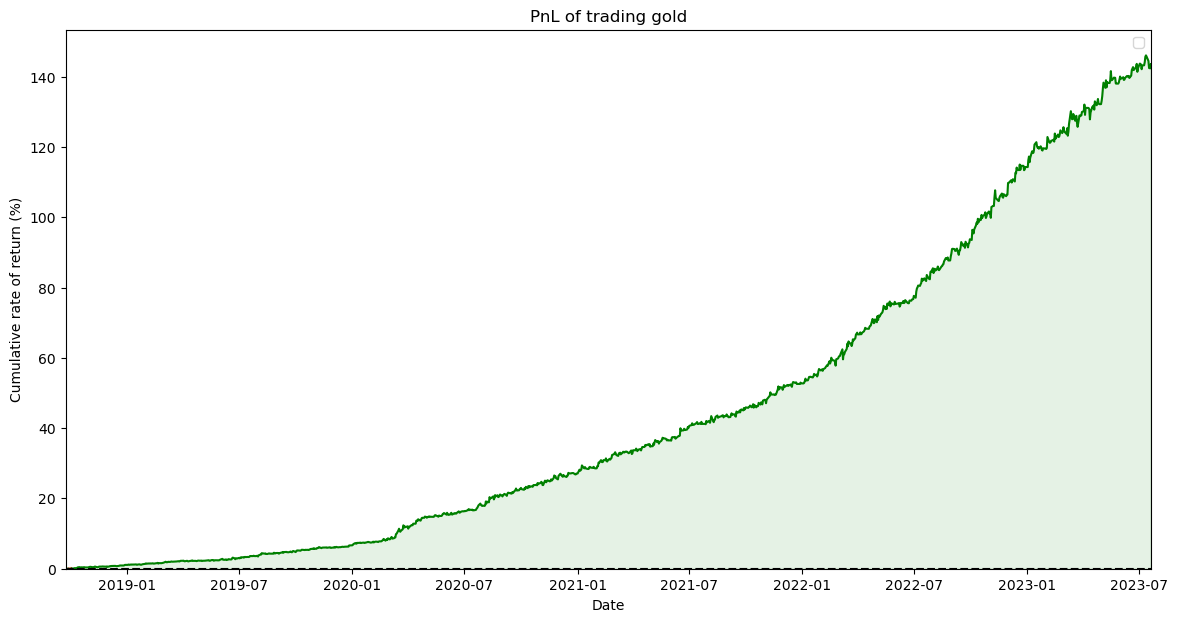

In [57]:
# Plot PnL chart
cum_rate_returns = pnl_df["Cumulative returns"] / initial_capital * 100
plt.figure(figsize=(14,7))
plt.plot(pnl_df.index, np.where(cum_rate_returns >= 0, cum_rate_returns, np.nan), color='green')
plt.plot(pnl_df.index, np.where(cum_rate_returns < 0, cum_rate_returns, np.nan), color='red')
plt.axhline(y=0, color="black", linestyle='--') # zero baseline
plt.fill_between(pnl_df.index, cum_rate_returns, 0, where=(cum_rate_returns >= 0), color='green', alpha=0.1)
plt.fill_between(pnl_df.index, cum_rate_returns, 0, where=(cum_rate_returns < 0), color='red', alpha=0.1)
plt.xlim(min(pnl_df.index), max(pnl_df.index))
plt.ylim(cum_rate_returns.min(), None)
plt.title(f"PnL of trading gold")
plt.xlabel("Date")
plt.ylabel("Cumulative rate of return (%)")
plt.legend()
plt.show()

In [58]:
# Returns performance metrics of the trading strategy
def get_metrics(df):
    
    metric_names = [
        "Cumulative rate of return",
        "Annualised rate of return",
        "Win rate",
        "Average win/loss ratio",
        "Profit factor",
        "Sharpe ratio",
        "Maximum drawdown"
    ]
    
    metrics = dict.fromkeys(metric_names, "")
    
    # Cumulative rate of return
    final_pnl = df["Cumulative returns"].iloc[-1]
    cum_return_pct = final_pnl / initial_capital
    metrics["Cumulative rate of return"] = f"{cum_return_pct * 100:.2f}%"

    # Annualised rate of return
    total_days = len(df)
    num_years = total_days / trading_days_per_year
    annual_return_pct = cum_return_pct / num_years
    metrics["Annualised rate of return"] = f"{annual_return_pct * 100:.2f}%"

    # Win rate
    up_days = df[df["Returns"] > 0]
    down_days = df[df["Returns"] < 0]
    neutral_days = df[df["Returns"] == 0]
    win_rate = len(up_days) / total_days
    metrics["Win rate"] = f"{win_rate * 100:.2f}%"

    # Average win/loss ratio
    avg_profit = up_days["Returns"].mean()
    avg_loss = abs(down_days["Returns"].mean())
    avg_win_loss_ratio = avg_profit / avg_loss
    metrics["Average win/loss ratio"] = f"{avg_win_loss_ratio:.2f}"

    # Profit factor
    gross_profit = up_days["Returns"].sum()
    gross_loss = abs(down_days["Returns"].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan
    metrics["Profit factor"] = f"{profit_factor:.2f}"

    # Sharpe ratio
    return_mean = df["Returns"].mean()
    return_std = df["Returns"].std()
    sharpe_ratio = (return_mean / return_std) * np.sqrt(trading_days_per_year)
    metrics["Sharpe ratio"] = f"{sharpe_ratio:.2f}"

    # Maximum drawdown
    def max_dd(ser):
        max_so_far = ser.cummax() # list of maximums up to each point
        dd_so_far = ser - max_so_far
        return int(dd_so_far.min())
    max_drawdown = max_dd(df["Returns"])
    metrics["Maximum drawdown"] = f"{max_drawdown}"

    res = [f"Performance metrics of trading gold"] + ["-------------------------------------"] + [f"{key}: {value}" for key, value in metrics.items()]
 
    return "\n".join(res)

In [59]:
# Get backtest results
print(get_metrics(test_data))

Performance metrics of trading gold
-------------------------------------
Cumulative rate of return: 143.61%
Annualised rate of return: 28.74%
Win rate: 57.51%
Average win/loss ratio: 1.23
Profit factor: 1.85
Sharpe ratio: 2.90
Maximum drawdown: -65945
